In [4]:
import pandas as pd

df = pd.read_excel(r"C:\Users\hp\Downloads\online+retail\Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Shape: (541909, 8)

Column Names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
print("Cancelled transactions:", df['InvoiceNo'].astype(str).str.startswith('C').sum())

print("Negative Quantity:", (df['Quantity'] < 0).sum())

print("Zero UnitPrice:", (df['UnitPrice'] == 0).sum())

Cancelled transactions: 9288
Negative Quantity: 10624
Zero UnitPrice: 2515


In [7]:
# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantity and positive price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

print("Rows after cleaning:", len(df))
print("Missing CustomerID:", df['CustomerID'].isnull().sum())


Rows after cleaning: 397884
Missing CustomerID: 0


In [8]:
import pandas as pd

# Reference date: one day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'UnitPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'TotalQuantity', 'TotalUnitPrice']

# Calculate total spending
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

monetary = df.groupby('CustomerID')['TotalAmount'].sum()

rfm['Monetary'] = monetary

rfm.head()


,Recency,Frequency,TotalQuantity,TotalUnitPrice,Monetary
CustomerID,,,,,
12346.0,326,1,74215,1.04,77183.60
12347.0,2,7,2458,481.21,4310.00
12348.0,75,4,2341,178.71,1797.24
12349.0,19,1,631,605.10,1757.55
12350.0,310,1,197,65.30,334.40


In [9]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [11]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.4 MB 5.1 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.4 MB 5.1 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.4 MB 5.1 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.4 MB 5.1 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.4 MB 4.9 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.4 MB 5.1 MB/s eta 0:00:01
   ------------------------------------- -- 7.9/8.4 MB 5.1 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 4.7 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [cloudpickle]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------------- ------------------- 2/4 [joblib]
   -------------

In [12]:
from sklearn.preprocessing import StandardScaler

# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


C:\Users\hp\miniconda3\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


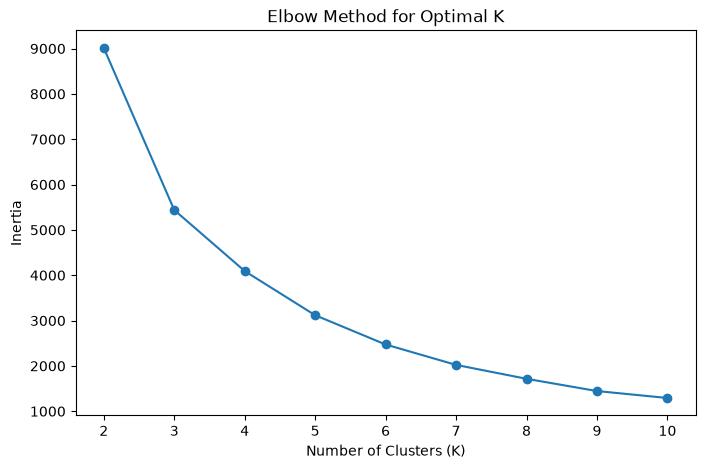

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()


In [14]:
from sklearn.cluster import KMeans

# Apply K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Check cluster labels
rfm.head()

,Recency,Frequency,TotalQuantity,TotalUnitPrice,Monetary,Cluster
CustomerID,,,,,,
12346.0,326,1,74215,1.04,77183.60,3
12347.0,2,7,2458,481.21,4310.00,0
12348.0,75,4,2341,178.71,1797.24,0
12349.0,19,1,631,605.10,1757.55,0
12350.0,310,1,197,65.30,334.40,1


In [15]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1359.05
1,248.08,1.55,480.62
2,7.38,82.54,127338.31
3,15.50,22.33,12709.09


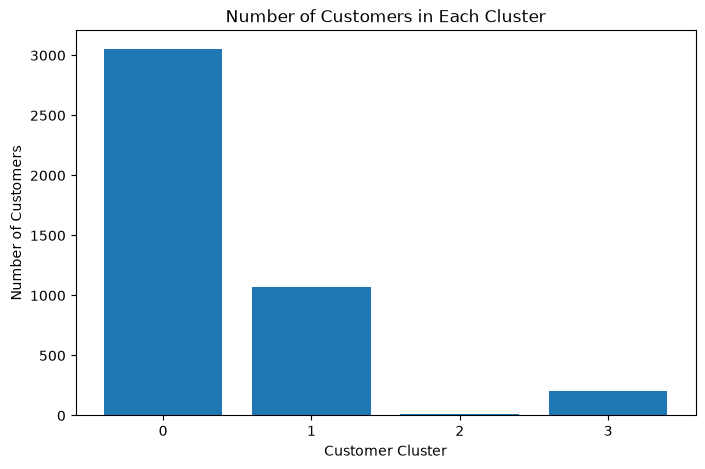

In [16]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.show()

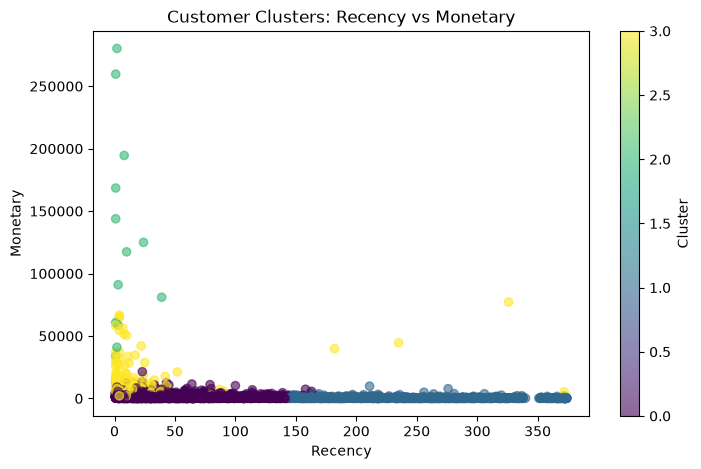

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Recency vs Monetary')
plt.colorbar(label='Cluster')
plt.show()

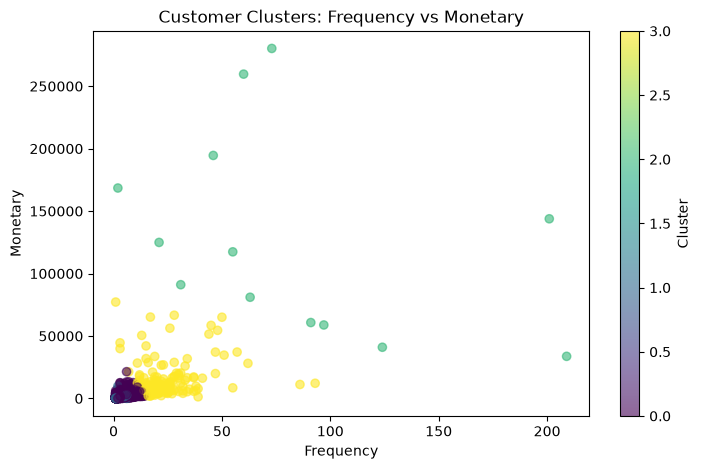

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Clusters: Frequency vs Monetary')
plt.colorbar(label='Cluster')
plt.show()

## Cluster Insights and Marketing Recommendations

### Cluster 0 – Regular / Potential Customers
These customers have moderate recency, frequency, and monetary value.
**Marketing Action:** Use personalised product recommendations, discounts, and cross-selling offers to increase purchase frequency and spending.

### Cluster 1 – At-Risk / Inactive Customers
These customers have high recency and low frequency and monetary value, indicating that they have not purchased recently.
**Marketing Action:** Use re-engagement campaigns, special discounts, and limited-time offers to encourage them to return.

### Cluster 2 – VIP / Champions
These customers have very low recency, extremely high purchase frequency, and extremely high monetary value. They are the most valuable customer segment.
**Marketing Action:** Provide VIP rewards, exclusive offers, early access to new products, and personalised loyalty benefits.

### Cluster 3 – Loyal High-Value Customers
These customers purchase frequently, have high monetary value, and have purchased recently.
**Marketing Action:** Strengthen loyalty through membership rewards, personalised recommendations, and exclusive promotions.

## Conclusion

The customer segmentation analysis successfully grouped customers into four distinct segments using RFM (Recency, Frequency, and Monetary) features and K-Means clustering.

The analysis identified regular customers, at-risk/inactive customers, VIP customers, and loyal high-value customers. These segments can help the business create targeted marketing strategies instead of using the same approach for all customers.

### Key Business Recommendations

1. **Retain VIP customers:** Provide exclusive rewards, early access, and personalised offers to the highest-value customers.

2. **Re-engage inactive customers:** Target at-risk customers with personalised discounts and limited-time offers to encourage repeat purchases.

3. **Increase customer value:** Use cross-selling, personalised recommendations, and loyalty programmes to increase the frequency and monetary value of regular customers.

In [19]:
# Customer-level purchase metrics

average_purchase_value = df['TotalAmount'].mean()

customer_purchase = df.groupby('CustomerID')['TotalAmount'].agg(
    TotalSpend='sum',
    PurchaseFrequency='nunique',
    AveragePurchaseValue='mean'
)

print("Average Purchase Value:", round(average_purchase_value, 2))

print("\nCustomer Purchase Statistics:")
customer_purchase[['PurchaseFrequency', 'AveragePurchaseValue', 'TotalSpend']].describe()

Average Purchase Value: 22.4

Customer Purchase Statistics:


,PurchaseFrequency,AveragePurchaseValue,TotalSpend
count,4338.000000,4338.000000,4338.000000
mean,32.868603,68.350506,2054.266460
std,33.382617,1467.918896,8989.230441
min,1.000000,2.101286,3.750000
25%,11.000000,12.365367,307.415000
50%,23.000000,17.723119,674.485000
75%,44.000000,24.858417,1661.740000
max,400.000000,77183.600000,280206.020000


## Data Cleaning and Handling Decisions

- Rows with missing `CustomerID` were removed because customer identification is essential for RFM-based customer segmentation.
- Cancelled transactions, identified by `InvoiceNo` starting with `C`, were removed.
- Transactions with negative `Quantity` were removed because they represent returns or adjustments rather than completed purchases.
- Transactions with zero `UnitPrice` were removed because they do not represent positive-value purchases.
- `InvoiceDate` was already stored as a datetime type.
- After cleaning, 397,884 valid transactions and 4,338 unique customers remained.
- RFM features were standardised using `StandardScaler` before applying K-Means clustering.